In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

In [6]:
# Step 1: Generate random points
N = 100_000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Step 2: Check if points are inside the unit circle
inside = x**2 + y**2 <= 1

# Step 3: Estimate π
pi_estimate = 4 * inside.sum() / N
print(f"Estimated π: {pi_estimate}")
print(f"True π: {np.pi}")

Estimated π: 3.14412
True π: 3.141592653589793


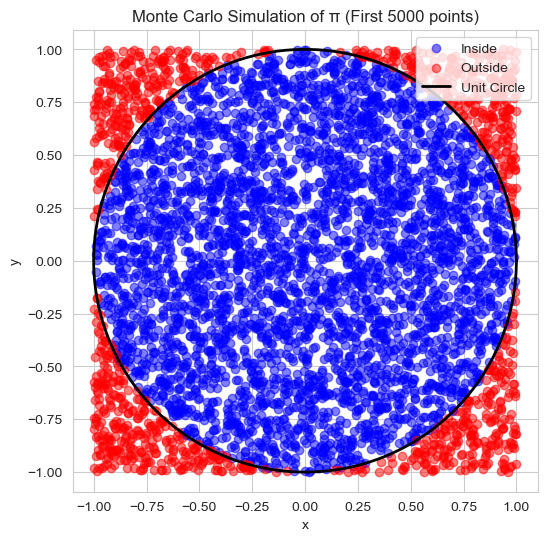

In [7]:
# Take first 5000 points for visualization
x_plot = x[:5000]
y_plot = y[:5000]
inside_plot = inside[:5000]

plt.figure(figsize=(6,6))
plt.scatter(x_plot[inside_plot], y_plot[inside_plot], color='blue', alpha=0.5, label='Inside')
plt.scatter(x_plot[~inside_plot], y_plot[~inside_plot], color='red', alpha=0.5, label='Outside')

# Draw the unit circle
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label='Unit Circle')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Monte Carlo Simulation of π (First 5000 points)")
plt.legend()
plt.axis('equal')  # equal aspect ratio
plt.show()

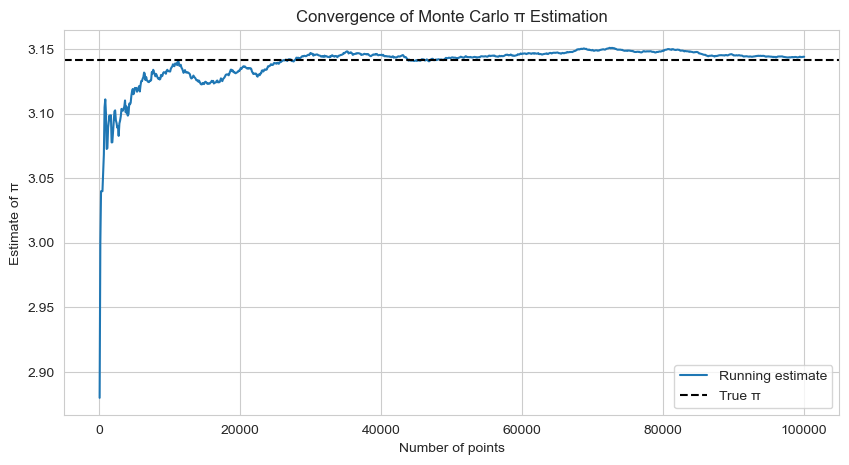

In [8]:
# Step 4: Running estimate
running_estimates = []
for i in range(100, N+1, 100):
    running_estimates.append(4 * inside[:i].sum() / i)

plt.figure(figsize=(10,5))
plt.plot(range(100, N+1, 100), running_estimates, label='Running estimate')
plt.axhline(np.pi, color='black', linestyle='--', label='True π')
plt.xlabel("Number of points")
plt.ylabel("Estimate of π")
plt.title("Convergence of Monte Carlo π Estimation")
plt.legend()
plt.show()

The estimate of π stabilizes within ±0.01 at around n ≈ 50000 points.

From the convergence plot, the estimate initially fluctuates significantly, but as the number of samples increases, it becomes more stable and stays close to the true value of π. This behavior is expected due to the law of large numbers.

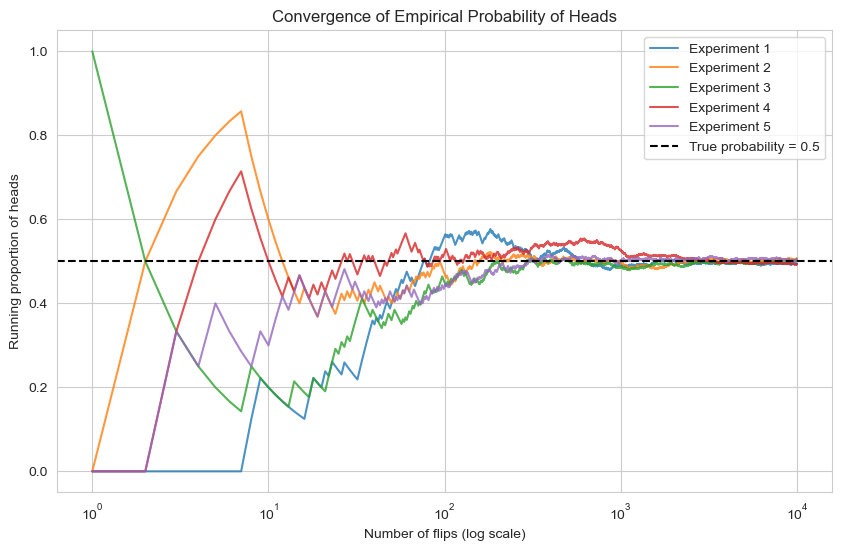

In [9]:
# Task 2: Coin flips and empirical probability

n_flips = 10_000
n_experiments = 5

all_running_props = []

plt.figure(figsize=(10, 6))

for exp in range(n_experiments):
    flips = np.random.binomial(1, 0.5, size=n_flips)
    running_heads = np.cumsum(flips)
    running_prop = running_heads / np.arange(1, n_flips + 1)
    all_running_props.append(running_prop)
    
    plt.plot(np.arange(1, n_flips + 1), running_prop, label=f"Experiment {exp+1}", alpha=0.8)

plt.axhline(0.5, linestyle="--", color="black", label="True probability = 0.5")
plt.xscale("log")
plt.xlabel("Number of flips (log scale)")
plt.ylabel("Running proportion of heads")
plt.title("Convergence of Empirical Probability of Heads")
plt.legend()
plt.show()

In [10]:
tolerance = 0.01
target = 0.5

for exp_num, running_prop in enumerate(all_running_props, start=1):
    stable_flip = None
    
    for i in range(len(running_prop)):
        if np.all(np.abs(running_prop[i:] - target) <= tolerance):
            stable_flip = i + 1
            break
    
    print(f"Experiment {exp_num}: stays within ±0.01 from flip {stable_flip}")

Experiment 1: stays within ±0.01 from flip 1487
Experiment 2: stays within ±0.01 from flip 1871
Experiment 3: stays within ±0.01 from flip 2428
Experiment 4: stays within ±0.01 from flip 2150
Experiment 5: stays within ±0.01 from flip 3387


The running proportion of heads fluctuates strongly at the beginning, especially during the first few flips. As the number of flips increases, the proportion gradually stabilizes near the true probability of 0.5.

Across the 5 experiments, the exact paths are different, but they all show the same general pattern: large early randomness followed by convergence. Typically, it takes several thousand flips for the running proportion to stay within ±0.01 of 0.5 consistently.

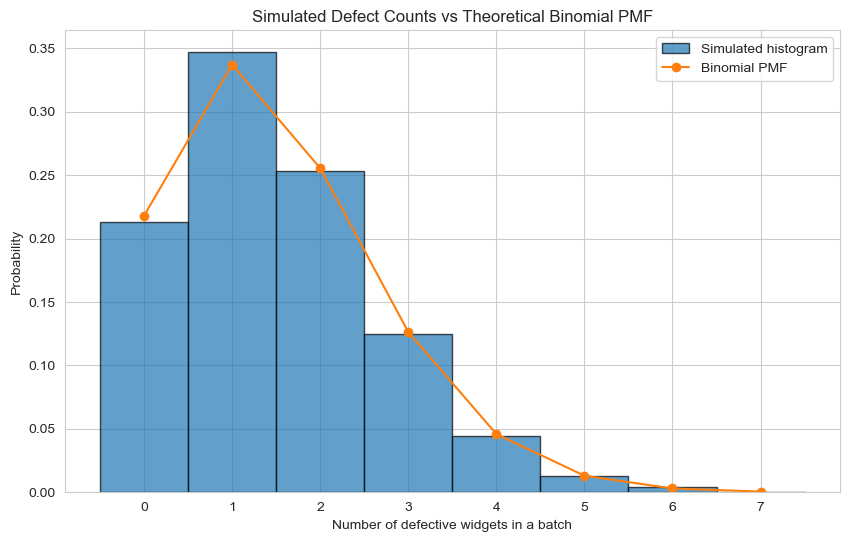

In [11]:
from scipy.stats import binom

# Parameters
n_batches = 10_000
n_widgets = 50
p_defect = 0.03

# Simulate the number of defects in each batch
defect_counts = np.random.binomial(n=n_widgets, p=p_defect, size=n_batches)

# Possible x-values for the theoretical binomial distribution
x_vals = np.arange(0, defect_counts.max() + 1)

# Theoretical PMF
pmf_vals = binom.pmf(x_vals, n=n_widgets, p=p_defect)

# Plot histogram as probabilities
plt.figure(figsize=(10, 6))
plt.hist(defect_counts, bins=np.arange(-0.5, defect_counts.max() + 1.5, 1),
         density=True, alpha=0.7, edgecolor='black', label='Simulated histogram')

# Overlay theoretical PMF
plt.plot(x_vals, pmf_vals, marker='o', linestyle='-', label='Binomial PMF')

plt.xlabel("Number of defective widgets in a batch")
plt.ylabel("Probability")
plt.title("Simulated Defect Counts vs Theoretical Binomial PMF")
plt.legend()
plt.show()

In [12]:
# Empirical estimates from the simulation
p_0_emp = np.mean(defect_counts == 0)
p_3plus_emp = np.mean(defect_counts >= 3)
expected_emp = np.mean(defect_counts)

print("Empirical estimates:")
print(f"P(0 defects)      = {p_0_emp:.6f}")
print(f"P(3 or more)      = {p_3plus_emp:.6f}")
print(f"E[X] defects      = {expected_emp:.6f}")

Empirical estimates:
P(0 defects)      = 0.213200
P(3 or more)      = 0.186700
E[X] defects      = 1.497800


In [13]:
# Theoretical binomial values
p_0_theory = binom.pmf(0, n=n_widgets, p=p_defect)
p_3plus_theory = 1 - binom.cdf(2, n=n_widgets, p=p_defect)
expected_theory = n_widgets * p_defect

print("Theoretical values:")
print(f"P(0 defects)      = {p_0_theory:.6f}")
print(f"P(3 or more)      = {p_3plus_theory:.6f}")
print(f"E[X] defects      = {expected_theory:.6f}")

Theoretical values:
P(0 defects)      = 0.218065
P(3 or more)      = 0.189202
E[X] defects      = 1.500000


In [14]:
comparison = pd.DataFrame({
    "Quantity": ["P(0 defects)", "P(3 or more defects)", "Expected defects"],
    "Empirical": [p_0_emp, p_3plus_emp, expected_emp],
    "Theoretical": [p_0_theory, p_3plus_theory, expected_theory]
})

comparison["Absolute Difference"] = np.abs(comparison["Empirical"] - comparison["Theoretical"])
comparison

,Quantity,Empirical,Theoretical,Absolute Difference
0,P(0 defects),0.2132,0.218065,0.004865
1,P(3 or more defects),0.1867,0.189202,0.002502
2,Expected defects,1.4978,1.500000,0.002200


The simulated histogram closely follows the shape of the theoretical Binomial(50, 0.03) distribution. Most batches contain 0, 1, or 2 defective widgets, while larger defect counts occur much less often.

The empirical estimates for P(0 defects), P(3 or more defects), and the expected number of defects are all very close to the theoretical values. This shows that the simulation is consistent with the binomial model.

Using 10,000 batches gives a fairly stable approximation. With only 1,000 batches, the estimates would still be reasonable, but they would usually fluctuate more and be less precise than with 10,000.